## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,5.319432,NaN,NaN,NaN,-0.739066,NaN,NaN,NaN,2.290183,NaN,NaN,NaN,7.036106,9.142565e+01,1.297637e+02,2.179013e+02,218.119280,31.387255,1.012492,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,0,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,6.769895,NaN,NaN,NaN,-0.479640,NaN,NaN,NaN,3.145128,NaN,NaN,NaN,9.791599,1.392955e+02,2.074087e+02,3.034552e+02,303.539567,31.000000,1.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567,0,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,NaN,NaN
2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184231,-0.670160,3.257036,7.231715,NaN,NaN,NaN,0.014150,NaN,NaN,NaN,3.622932,NaN,NaN,NaN,8.572965,1.408672e+02,1.873860e+02,2.657269e+02,265.761927,31.000000,1.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.0,1.0,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927,0,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.6666

<AxesSubplot:>

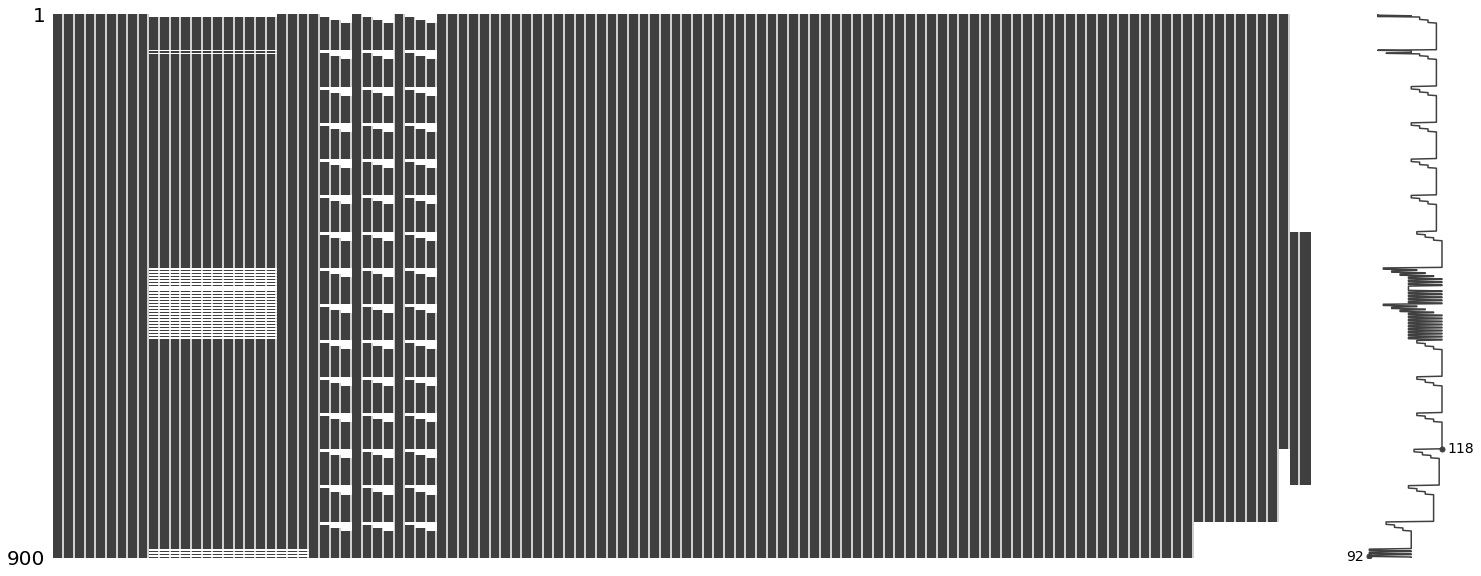

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,9.8889
1,ndmi,9.8889
2,ndwi,9.8889
3,ndbi,9.8889
4,ndvi_mean,9.8889
...,...,...
30,F_Y_GE65,6.6667
31,F_TOTAL,6.6667
32,MIO_EUR,20.0000
33,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_NAME.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst_mean'].min()
        mean_temp_q1 = q1_df['lst_mean'].mean()
        max_temp_q1 = q1_df['lst_mean'].max()
        prec_q1 = q1_df['rainfall_mean'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst_mean'].min()
        mean_temp_q2 = q2_df['lst_mean'].mean()
        max_temp_q2 = q2_df['lst_mean'].max()
        prec_q2 = q2_df['rainfall_mean'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst_mean'].min()
        mean_temp_q3 = q3_df['lst_mean'].mean()
        max_temp_q3 = q3_df['lst_mean'].max()
        prec_q3 = q3_df['rainfall_mean'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst_mean'].min()
        mean_temp_q4 = q4_df['lst_mean'].mean()
        max_temp_q4 = q4_df['lst_mean'].max()
        prec_q4 = q4_df['rainfall_mean'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,NUTS3_NAME,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,εβρος,2009,1.824858,5.067991,7.468260,18.656614,0.230845,-0.192215,0.006230,-0.006230,0.231478,-0.199918,0.002718,-0.002718,0.026614,0.038716,0.029301,0.029301,1.824858,12.138647,24.090948,24.997892,0.369739,-0.267717,0.081465,-0.081465,0.369794,-0.267377,0.083012,-0.083012,0.042822,0.033710,0.044769,0.044769,1.824858,16.478941,26.513116,33.061502,0.389426,-0.289373,0.083969,-0.083969,0.387999,-0.288087,0.084458,-0.084458,0.049103,0.034368,0.049478,0.049478,1.824858,15.126292,26.513116,55.678010,0.375135,-0.272274,0.079810,-0.079810,0.371736,-0.269534,0.079773,-0.079773,0.048853,0.036316,0.049036,0.049036
1,ξανθη,2009,2.808656,5.257045,7.817738,20.603354,0.191306,-0.230485,-0.040271,0.040271,0.177326,-0.212300,-0.036122,0.036122,0.031158,0.055193,0.034751,0.034751,2.808656,11.917971,22.421875,30.679384,0.341663,-0.291689,0.040486,-0.040486,0.333816,-0.278067,0.045491,-0.045491,0.040438,0.042940,0.043879,0.043879,2.808656,15.905174,25.022198,37.995653,0.407336,-0.319429,0.079818,-0.079818,0.402630,-0.309809,0.083927,-0.083927,0.047585,0.037645,0.050514,0.050514,2.808656,14.724391,25.022198,55.913993,0.393013,-0.311171,0.068830,-0.068830,0.384832,-0.299564,0.071448,-0.071448,0.048602,0.045028,0.051578,0.051578
2,ροδοπη,2009,3.257036,5.610730,8.005242,20.112371,0.156491,-0.118417,0.022756,-0.022756,0.143164,-0.113059,0.018565,-0.018565,0.013055,0.020734,0.018680,0.018680,3.257036,12.774382,24.751801,27.991547,0.297046,-0.242683,0.047476,-0.047476,0.294529,-0.238574,0.050317,-0.050317,0.037476,0.030614,0.041620,0.041620,3.257036,16.980108,26.776309,34.400204,0.349617,-0.277868,0.069035,-0.069035,0.345848,-0.275921,0.068680,-0.068680,0.046431,0.032970,0.049814,0.049814,3.257036,15.632362,26.776309,54.390851,0.319487,-0.258997,0.054160,-0.054160,0.315409,-0.254002,0.056126,-0.056126,0.045256,0.039850,0.049782,0.049782
3,δραμα,2009,1.344252,3.425689,5.466764,16.951080,0.213823,-0.049571,0.138859,-0.138859,0.214010,-0.056927,0.138018,-0.138018,0.048145,0.109245,0.075295,0.075295,1.344252,10.186755,20.756685,27.876272,0.337630,-0.155440,0.153547,-0.153547,0.339558,-0.160513,0.153700,-0.153700,0.049553,0.081855,0.068407,0.068407,1.344252,14.171414,22.975630,36.653997,0.420114,-0.208888,0.179988,-0.179988,0.416601,-0.210058,0.178239,-0.178239,0.049346,0.068053,0.061589,0.061589,1.344252,12.955952,22.975630,51.299956,0.409236,-0.216129,0.158768,-0.158768,0.405454,-0.216906,0.156721,-0.156721,0.050670,0.073850,0.061481,0.061481
4,"θασος, καβαλα",2009,3.773339,5.811993,7.876259,17.121152,0.324423,-0.195373,0.082923,-0.082923,0.314786,-0.184936,0.085005,-0.085005,0.052496,0.076333,0.061844,0.061844,3.773339,12.378657,22.941748,26.178482,0.390267,-0.240506,0.112425,-0.112425,0.385855,-0.232635,0.115746,-0.115746,0.052399,0.056934,0.060752,0.060752,3.773339,16.407771,25.552116,32.826030,0.428871,-0.273556,0.123961,-0.123961,0.426317,-0.265619,0.128669,-0.128669,0.054049,0.049009,0.061830,0.061830,3.773339,15.262124,25.552116,49.481246,0.421279,-0.266201,0.118789,-0.118789,0.417859,-0.256982,0.123489,-0.123489,0.057114,0.060250,0.065587,0.065587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['NUTS3_NAME', 'year'])

In [10]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,5.319432,NaN,NaN,NaN,-0.739066,NaN,NaN,NaN,2.290183,NaN,NaN,NaN,7.036106,9.142565e+01,1.297637e+02,2.179013e+02,218.119280,31.387255,1.012492,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,0,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN,1.824858,5.067991,7.468260,18.656614,0.230845,-0.192215,0.006230,-0.006230,0.231478,-0.199918,0.002718,-0.002718,0.026614,0.038716,0.029301,0.029301,1.824858,12.138647,24.090948,24.997892,0.369739,-0.267717,0.081465,-0.081465,0.369794,-0.267377,0.083012,-0.083012,0.042822,0.033710,0.044769,0.044769,1.824858,16.478941,26.513116,33.061502,0.389426,-0.289373,0.083969,-0.083969,0.387999,-0.288087,0.084458,-0.084458,0.049103,0.034368,0.049478,0.049478,1.824858,15.126292,26.513116,55.678010,0.375135,-0.272274,0.079810,-0.079810,0.371736,-0.269534,0.079773,-0.079773,0.048853,0.036316,0.049036,0.049036
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,6.769895,NaN,NaN,NaN,-0.479640,NaN,NaN,NaN,3.145128,NaN,NaN,NaN,9.791599,1.392955e+02,2.074087e+02,3.034552e+02,303.539567,31.000000,1.000000,18108.962476,1475.56303

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,6.5,0.375135,0.079810,-0.272274,-0.079810,0.371736,0.079773,-0.269534,-0.079773,0.048853,0.049036,0.036316,0.049036,21.134571,9.118013,15.126292,5.319432,9.448205,14.314735,15.167433,-0.739066,2.375193,0.624374,1.203811,2.290183,5.911699,7.469555,8.185622,4.639834,21.289758,48.966146,137.067235,845.187965,72.438725,2.376471,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0.0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32.0,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,4.813837,26.518333,141.039700,0.0,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN,1.824858,5.067991,7.468260,18.656614,0.230845,-0.192215,0.006230,-0.006230,0.231478,-0.199918,0.002718,-0.002718,0.026614,0.038716,0.029301,0.029301,1.824858,12.138647,24.090948,24.997892,0.369739,-0.267717,0.081465,-0.081465,0.369794,-0.267377,0.083012,-0.083012,0.042822,0.033710,0.044769,0.044769,1.824858,16.478941,26.513116,33.061502,0.389426,-0.289373,0.083969,-0.083969,0.387999,-0.288087,0.084458,-0.084458,0.049103,0.034368,0.049478,0.049478,1.824858,15.126292,26.513116,55.678010,0.375135,-0.272274,0.079810,-0.079810,0.371736,-0.269534,0.079773,-0.079773,0.048853,0.036316,0.049036,0.049036
1,2009,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,6.5,0.393013,0.068830,-0.311171,-0.068830,0.384832,0.071448,-0.299564,-0.071448,0.048602,0.051578,0.045028,0.051578,20.246626,9.202156,14.7243

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,314.113272,494.665914,78,4.126484,0.877915,-2.995013,-0.877915,4.089098,0.877508,-2.964870,-0.877508,0.537383,0.539391,0.399478,0.539391,253.614847,109.416153,181.515500,63.833184,103.930259,143.147355,136.506894,-8.868795,26.127121,6.243741,10.834302,27.482194,65.028690,74.695548,73.670598,55.678010,255.477098,587.593757,1644.806817,10142.255582,869.264706,28.517651,162972.628684,17371.473733,90.647059,1885.599626,2251.137712,2138.569300,0.029277,760.575747,4233.776572,27.018121,0,523.136880,17.931665,1576.328433,0.0,12.0,459085.593538,52329.860111,384,3726.693307,13537.462418,2399.066075,5.346544,55243.069500,100172.314148,12816.519486,74.747608,598.608152,2093.387596,77.292842,0.375634,4165.853600,372,432,360,144,144,36,60,96,24,57.766040,318.220000,1692.476395,0,184.0,258.0,526.530612,11108.718934,492.0,-96.0,588.0,52.0,320.0,320.0,52.0,20256.0,4332.0,72.0,802.082072,9180.0,1932.0,1932.0,9180.0,131616.0,602592.0,179244.0,913452.0,119100.0,520896.0,220596.0,860592.0,27733.20,0.0,0.0,21.898297,60.815891,89.619124,223.879372,2.770138,-2.306585,0.074763,-0.074763,2.777737,-2.399018,0.032618,-0.032618,0.319374,0.464589,0.351606,0.351606,21.898297,145.663769,289.091380,299.974699,4.436862,-3.212603,0.977578,-0.977578,4.437527,-3.208527,0.996143,-0.996143,0.513865,0.404515,0.537224,0.537224,21.898297,197.747289,318.157394,396.738020,4.673114,-3.472481,1.007633,-1.007633,4.655994,-3.457045,1.013500,-1.013500,0.589238,0.412417,0.593734,0.593734,21.898297,181.515500,318.157394,668.136117,4.501619,-3.267287,0.957725,-0.957725,4.460834,-3.234403,0.957282,-0.957282,0.586237,0.435794,0.588427,0.588427
1,2009,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,298.704714,494.032311,78,4.323144,0.757126,-3.422885,-0.757126,4.233156,0.785925,-3.295207,-0.785925,0.534

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(75, 180)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred_mean'] = dataset_annual_cases['mosq_pred_mean']

<AxesSubplot:>

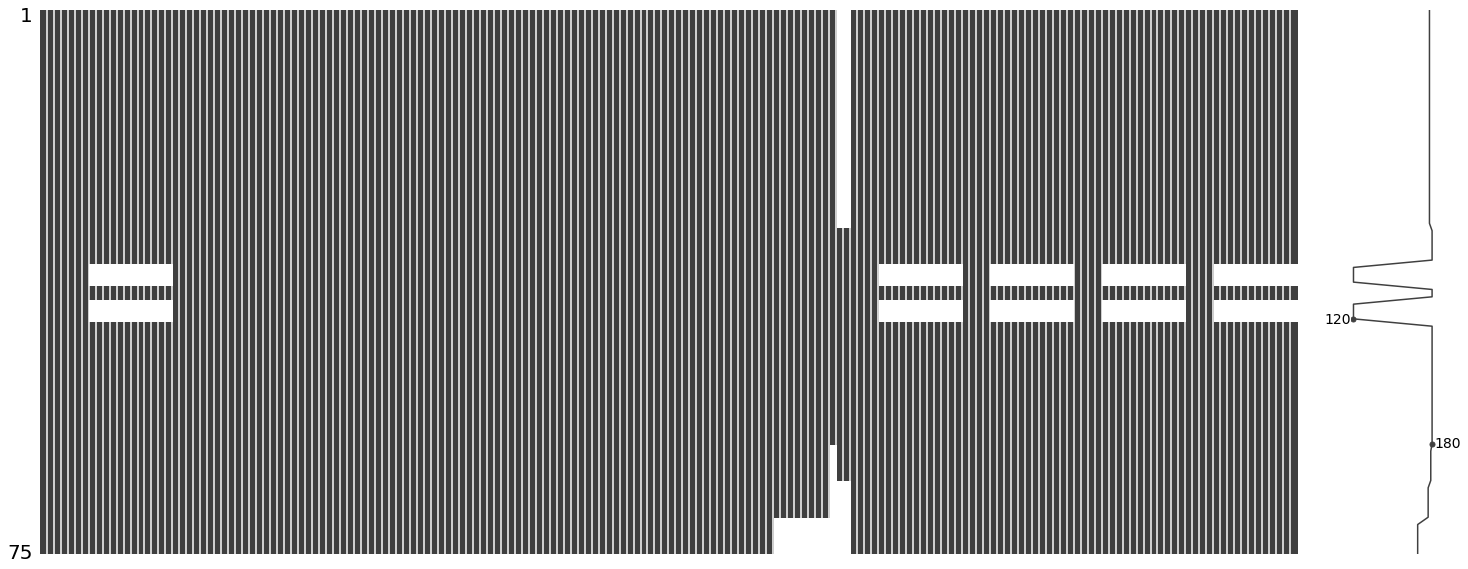

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,ndvi,8.0
1,ndmi,8.0
2,ndwi,8.0
3,ndbi,8.0
4,ndvi_mean,8.0
...,...,...
66,ndbi_mean_q4,8.0
67,ndvi_std_q4,8.0
68,ndwi_std_q4,8.0
69,ndmi_std_q4,8.0


In [17]:
dataset_annual.head(15)

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,0.375135,0.079810,-0.272274,-0.079810,0.371736,0.079773,-0.269534,-0.079773,0.048853,0.049036,0.036316,0.049036,21.134571,9.118013,15.126292,5.319432,9.448205,14.314735,15.167433,-0.739066,2.375193,0.624374,1.203811,2.290183,5.911699,7.469555,8.185622,4.639834,21.289758,48.966146,137.067235,845.187965,72.438725,28.517651,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0.0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32.0,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,4.813837,26.518333,141.039700,0,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN,1.824858,5.067991,7.468260,18.656614,0.230845,-0.192215,0.006230,-0.006230,0.231478,-0.199918,0.002718,-0.002718,0.026614,0.038716,0.029301,0.029301,1.824858,12.138647,24.090948,24.997892,0.369739,-0.267717,0.081465,-0.081465,0.369794,-0.267377,0.083012,-0.083012,0.042822,0.033710,0.044769,0.044769,1.824858,16.478941,26.513116,33.061502,0.389426,-0.289373,0.083969,-0.083969,0.387999,-0.288087,0.084458,-0.084458,0.049103,0.034368,0.049478,0.049478,1.824858,15.126292,26.513116,55.678010,0.375135,-0.272274,0.079810,-0.079810,0.371736,-0.269534,0.079773,-0.079773,0.048853,0.036316,0.049036,0.049036
1,2009,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,0.393013,0.068830,-0.311171,-0.068830,0.384832,0.071448,-0.299564,-0.071448,0.048602,0.051578,0.045028,0.051578,20.246626,9.202156,14.724391,6.769895,8.4

In [18]:
dataset_annual.cases.sum()

282

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

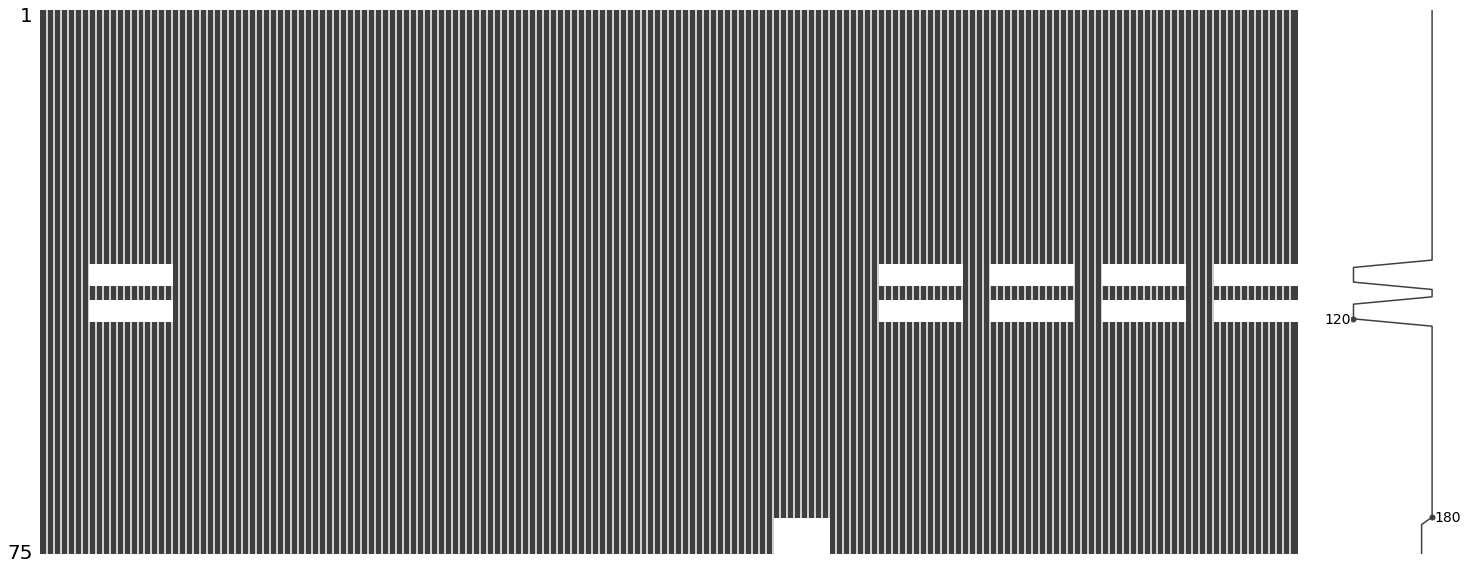

In [22]:
missingno.matrix(dataset_annual, label_rotation=90)

<AxesSubplot:>

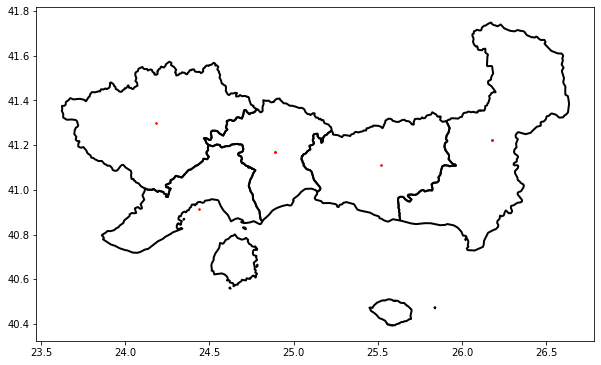

In [23]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_annual[['NUTS3_NAME']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [24]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['NUTS3_NAME'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['NUTS3_NAME'] == region)]

        data_q1.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [25]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,6.133541,8.969876,26.545676,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.290802,-0.218385,0.067353,-0.067353,0.279660,-0.190116,0.083387,-0.083387,0.043415,0.056153,0.044260,0.044260,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,5.880465,9.080629,21.265302,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.250468,-0.092342,0.154727,-0.154727,0.228891,-0.056728,0.169125,-0.169125,0.042733,0.079290,0.069691,0.069691,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,6.081173,9.112399,22.547792,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.247863,-0.194135,0.048665,-0.048665,0.237869,-0.186190,0.047189,-0.047189,0.044400,0.051977,0.045770,0.045770,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,4.027745,7.557022,17.512677,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.201156,0.065116,0.241013,-0.241013,0.199397,0.069909,0.246509,-0.246509,0.038718,0.087202,0.069770,0.069770,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,6.929530,9.689489,17.067119,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.232268,-0.045789,0.163353,-0.163353,0.229594,-0.041304,0.166244,-0.166244,0.043449,0.074858,0.060325,0.060325,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,5.56402

In [26]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,12.973635,24.276070,35.004733,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.424772,-0.271447,0.134295,-0.134295,0.415725,-0.259124,0.137783,-0.137783,0.051285,0.040181,0.050570,0.050570,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,12.256258,22.300438,31.904804,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.367528,-0.200248,0.159253,-0.159253,0.354388,-0.179193,0.167038,-0.167038,0.049797,0.062546,0.064659,0.064659,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,13.259302,24.870309,31.396320,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.327695,-0.252665,0.070876,-0.070876,0.320642,-0.247689,0.069684,-0.069684,0.052423,0.047513,0.054068,0.054068,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,10.578711,20.514354,28.836547,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.345276,-0.092227,0.227714,-0.227714,0.346253,-0.090139,0.231016,-0.231016,0.044230,0.071193,0.063126,0.063126,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,13.200940,22.632630,26.659480,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.337753,-0.165592,0.148807,-0.148807,0.336526,-0.156036,0.157182,-0.157182,0.049517,0.060386,0.059265,0.059265,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.22

In [27]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,17.214678,28.943415,42.136317,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.431764,-0.286335,0.124240,-0.124240,0.427861,-0.279468,0.127176,-0.127176,0.052461,0.040108,0.052560,0.052560,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,16.203761,27.033427,40.842188,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.415453,-0.245070,0.159079,-0.159079,0.405317,-0.229349,0.164559,-0.164559,0.051082,0.053144,0.060980,0.060980,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,17.551566,28.945278,39.506386,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.373404,-0.278991,0.089042,-0.089042,0.368053,-0.274614,0.088407,-0.088407,0.054741,0.043995,0.056992,0.056992,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,14.664333,25.639173,36.657424,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.414347,-0.167866,0.219621,-0.219621,0.413701,-0.164392,0.221934,-0.221934,0.047316,0.063366,0.060606,0.060606,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,17.144154,27.845846,32.334555,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.389196,-0.211860,0.152278,-0.152278,0.384985,-0.201513,0.158240,-0.158240,0.051564,0.053825,0.060870,0.060870,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.22

In [28]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,15.601087,28.943415,60.948494,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.400835,-0.263939,0.113463,-0.113463,0.398782,-0.258642,0.116495,-0.116495,0.051955,0.042904,0.052977,0.052977,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,14.739085,27.033427,57.789427,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.400061,-0.249101,0.136410,-0.136410,0.387831,-0.231703,0.140986,-0.140986,0.050575,0.055332,0.059407,0.059407,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,15.888446,28.945278,57.374695,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.357754,-0.275813,0.072497,-0.072497,0.356357,-0.274637,0.072700,-0.072700,0.053505,0.045559,0.056425,0.056425,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,13.092531,25.639173,52.320076,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.400182,-0.181250,0.190864,-0.190864,0.399843,-0.179403,0.192408,-0.192408,0.049028,0.069267,0.060809,0.060809,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,15.626308,27.845846,49.255590,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.392283,-0.219307,0.142172,-0.142172,0.388059,-0.208107,0.148451,-0.148451,0.053802,0.059690,0.063486,0.063486,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.22

In [29]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

282
282
282
282


In [30]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

282
282
282
282


In [31]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,6.133541,8.969876,26.545676,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.290802,-0.218385,0.067353,-0.067353,0.279660,-0.190116,0.083387,-0.083387,0.043415,0.056153,0.044260,0.044260,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,5.880465,9.080629,21.265302,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.250468,-0.092342,0.154727,-0.154727,0.228891,-0.056728,0.169125,-0.169125,0.042733,0.079290,0.069691,0.069691,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,6.081173,9.112399,22.547792,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.247863,-0.194135,0.048665,-0.048665,0.237869,-0.186190,0.047189,-0.047189,0.044400,0.051977,0.045770,0.045770,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,4.027745,7.557022,17.512677,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.201156,0.065116,0.241013,-0.241013,0.199397,0.069909,0.246509,-0.246509,0.038718,0.087202,0.069770,0.069770,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,6.929530,9.689489,17.067119,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.232268,-0.045789,0.163353,-0.163353,0.229594,-0.041304,0.166244,-0.166244,0.043449,0.074858,0.060325,0.060325,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,5.56402

In [32]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,12.973635,24.276070,35.004733,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.424772,-0.271447,0.134295,-0.134295,0.415725,-0.259124,0.137783,-0.137783,0.051285,0.040181,0.050570,0.050570,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,12.256258,22.300438,31.904804,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.367528,-0.200248,0.159253,-0.159253,0.354388,-0.179193,0.167038,-0.167038,0.049797,0.062546,0.064659,0.064659,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,13.259302,24.870309,31.396320,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.327695,-0.252665,0.070876,-0.070876,0.320642,-0.247689,0.069684,-0.069684,0.052423,0.047513,0.054068,0.054068,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,10.578711,20.514354,28.836547,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.345276,-0.092227,0.227714,-0.227714,0.346253,-0.090139,0.231016,-0.231016,0.044230,0.071193,0.063126,0.063126,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,13.200940,22.632630,26.659480,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.337753,-0.165592,0.148807,-0.148807,0.336526,-0.156036,0.157182,-0.157182,0.049517,0.060386,0.059265,0.059265,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.22

In [33]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,17.214678,28.943415,42.136317,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.431764,-0.286335,0.124240,-0.124240,0.427861,-0.279468,0.127176,-0.127176,0.052461,0.040108,0.052560,0.052560,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,16.203761,27.033427,40.842188,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.415453,-0.245070,0.159079,-0.159079,0.405317,-0.229349,0.164559,-0.164559,0.051082,0.053144,0.060980,0.060980,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,17.551566,28.945278,39.506386,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.373404,-0.278991,0.089042,-0.089042,0.368053,-0.274614,0.088407,-0.088407,0.054741,0.043995,0.056992,0.056992,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,14.664333,25.639173,36.657424,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.414347,-0.167866,0.219621,-0.219621,0.413701,-0.164392,0.221934,-0.221934,0.047316,0.063366,0.060606,0.060606,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,17.144154,27.845846,32.334555,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.389196,-0.211860,0.152278,-0.152278,0.384985,-0.201513,0.158240,-0.158240,0.051564,0.053825,0.060870,0.060870,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.22

In [34]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3.983855,15.601087,28.943415,60.948494,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,0.400835,-0.263939,0.113463,-0.113463,0.398782,-0.258642,0.116495,-0.116495,0.051955,0.042904,0.052977,0.052977,76121.0,10968.0,50216.0,14937.0,71716.0,9925.0,43408.0,18383.0,2311.100,1863.2,1751.2,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,28.517651,0
1,2010,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,3.754185,14.739085,27.033427,57.789427,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,0.400061,-0.249101,0.136410,-0.136410,0.387831,-0.231703,0.140986,-0.140986,0.050575,0.055332,0.059407,0.059407,55122.0,10590.0,37198.0,7334.0,55817.0,9955.0,36599.0,9263.0,1544.090,1863.2,1751.2,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,31.0,36.0,30.0,12.0,12.0,3.0,4.0,4.0,2.0,15.901962,0
2,2010,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,3.949193,15.888446,28.945278,57.374695,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,0.357754,-0.275813,0.072497,-0.072497,0.356357,-0.274637,0.072700,-0.072700,0.053505,0.045559,0.056425,0.056425,54265.0,8312.0,36363.0,9590.0,57464.0,7809.0,37741.0,11914.0,1637.960,1863.2,1751.2,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,16.682518,0
3,2010,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,2.068316,13.092531,25.639173,52.320076,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,0.400182,-0.181250,0.190864,-0.190864,0.399843,-0.179403,0.192408,-0.192408,0.049028,0.069267,0.060809,0.060809,47810.0,7608.0,29799.0,10403.0,50357.0,6962.0,29625.0,13770.0,1314.360,1863.2,1751.2,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,31.0,10.0,10.0,4.0,4.0,6.0,4.0,4.0,2.0,35.980787,0
4,2010,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,4.995118,15.626308,27.845846,49.255590,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,0.392283,-0.219307,0.142172,-0.142172,0.388059,-0.208107,0.148451,-0.148451,0.053802,0.059690,0.063486,0.063486,68641.0,10674.0,44339.0,13628.0,71326.0,9802.0,44104.0,17420.0,2498.510,1863.2,1751.2,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,31.0,20.0,30.0,9.0,9.0,4.0,1.0,1.0,2.0,32.431432,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.22

In [35]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2010_2023.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2010_2023.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2010_2023.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2010_2023.csv", encoding = enc, index = False)